# Router Capacity Planning & Feasibility

This notebook helps answer the question: **"Given my latency/cost constraints, can any combination of models satisfy my requirements?"**

**Goals:**
1.  **Load Model Profiles**: Analyze average latency, cost, and accuracy for each model.
2.  **Define SLAs**: Set your budget and speed limits.
3.  **Check Feasibility**: Automatically determine if a configuration is realistic.

---

In [19]:
# 1. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Optional, Dict, Any
import sys
import os
from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)

current_dir = Path(os.getcwd())
project_root = current_dir.parent.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project Root: {project_root}")

Project Root: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router


In [20]:
# 2. Load Model Profiles
def load_model_profiles() -> pd.DataFrame:
    """
    Loads real profiling data from parquet or falls back to synthetic data.
    """
    parquet_path = project_root / "examples/data/router_profiles_with_utility.parquet"
    
    if parquet_path.exists():
        print(f"Loading real data from {parquet_path.name}...")
        try:
            df = pd.read_parquet(parquet_path)
            
            # Aggregate if we have raw request logs (checking for sample_id or latency_ms)
            if 'sample_id' in df.columns or 'latency_ms' in df.columns:
                print(f"   - Found {len(df)} raw rows. Aggregating by model_name...")
                
                # Determine available columns to aggregate
                agg_dict = {}
                if 'latency_ms' in df.columns: agg_dict['latency_ms'] = 'mean'
                if 'estimated_cost_usd' in df.columns: agg_dict['estimated_cost_usd'] = 'mean'
                if 'utility_accuracy' in df.columns: 
                    agg_dict['utility_accuracy'] = 'mean'
                elif 'is_correct' in df.columns:
                    agg_dict['is_correct'] = 'mean'
                
                # Perform aggregation
                profiles = df.groupby('model_name').agg(agg_dict).reset_index()
                
                # Rename to standard expected schema
                rename_map = {
                    'latency_ms': 'avg_latency_ms',
                    'estimated_cost_usd': 'avg_cost_usd',
                    'utility_accuracy': 'avg_accuracy',
                    'is_correct': 'avg_accuracy'
                }
                profiles.rename(columns=rename_map, inplace=True)
                return profiles
            
            return df # Assume already aggregated if simple schema
        except Exception as e:
            print(f"Error reading parquet: {e}")
    
    print("Using Synthetic Fallback Data")
    return pd.DataFrame({
        'model_name': ['fast_v1', 'balanced_v2', 'accurate_v1'],
        'avg_latency_ms': [150.0, 500.0, 2000.0],
        'avg_cost_usd': [0.001, 0.005, 0.02],
        'avg_accuracy': [0.85, 0.92, 0.98]
    })

profiles = load_model_profiles()
print("\n=== Model Profiles ===")
display(profiles)

Using Synthetic Fallback Data

=== Model Profiles ===


,model_name,avg_latency_ms,avg_cost_usd,avg_accuracy
0,fast_v1,150.0,0.001,0.85
1,balanced_v2,500.0,0.005,0.92
2,accurate_v1,2000.0,0.020,0.98


In [21]:
# 3. Define Feasibility Checker
@dataclass
class SLAConfig:
    name: str
    max_latency_ms: float
    max_cost_usd: float
    min_accuracy: float

def check_feasibility(sla: SLAConfig, df: pd.DataFrame) -> Dict[str, Any]:
    print(f"\nChecking SLA: {sla.name}")
    
    if df.empty:
        print("No model profiles available to check.")
        return {'feasible': False, 'candidates': []}

    # Filtering
    try:
        candidates = df[
            (df['avg_latency_ms'] <= sla.max_latency_ms) &
            (df['avg_cost_usd'] <= sla.max_cost_usd) &
            (df['avg_accuracy'] >= sla.min_accuracy)
        ]
    except KeyError as e:
        print(f"Missing columns in profile data: {e}")
        return {'feasible': False, 'candidates': []}
    
    feasible = not candidates.empty
    
    # Compute Bounds
    stats = {
        'min_latency': df['avg_latency_ms'].min(),
        'min_cost': df['avg_cost_usd'].min(),
        'max_accuracy': df['avg_accuracy'].max()
    }
    
    if feasible:
        print(f"  FEASIBLE with {len(candidates)} models: {candidates['model_name'].tolist()}")
    else:
        print(f"  INFEASIBLE")
        if sla.max_latency_ms < stats['min_latency']:
            print(f"     - Latency SLA ({sla.max_latency_ms}ms) is faster than fastest model ({stats['min_latency']:.1f}ms)")
        if sla.max_cost_usd < stats['min_cost']:
            print(f"     - Cost Budget (${sla.max_cost_usd}) is lower than cheapest model (${stats['min_cost']:.4f})")
        if sla.min_accuracy > stats['max_accuracy']:
            print(f"     - Accuracy Target ({sla.min_accuracy}) exceeds best model ({stats['max_accuracy']:.2f})")
            
    return {'feasible': feasible, 'candidates': candidates['model_name'].tolist()}

In [22]:
# 4. Run Scenarios
scenarios = [
    SLAConfig("Standard", max_latency_ms=1000, max_cost_usd=0.01, min_accuracy=0.9),
    SLAConfig("Ultra Low Latency", max_latency_ms=50, max_cost_usd=1.0, min_accuracy=0.8),
    SLAConfig("High Accuracy", max_latency_ms=5000, max_cost_usd=0.05, min_accuracy=0.99),
]

results = []
for s in scenarios:
    res = check_feasibility(s, profiles)
    results.append({
        'Scenario': s.name,
        'Feasible': res['feasible'],
        'Models': len(res['candidates'])
    })

pd.DataFrame(results)


Checking SLA: Standard
  FEASIBLE with 1 models: ['balanced_v2']

Checking SLA: Ultra Low Latency
  INFEASIBLE
     - Latency SLA (50ms) is faster than fastest model (150.0ms)

Checking SLA: High Accuracy
  INFEASIBLE
     - Accuracy Target (0.99) exceeds best model (0.98)


,Scenario,Feasible,Models
0,Standard,True,1
1,Ultra Low Latency,False,0
2,High Accuracy,False,0


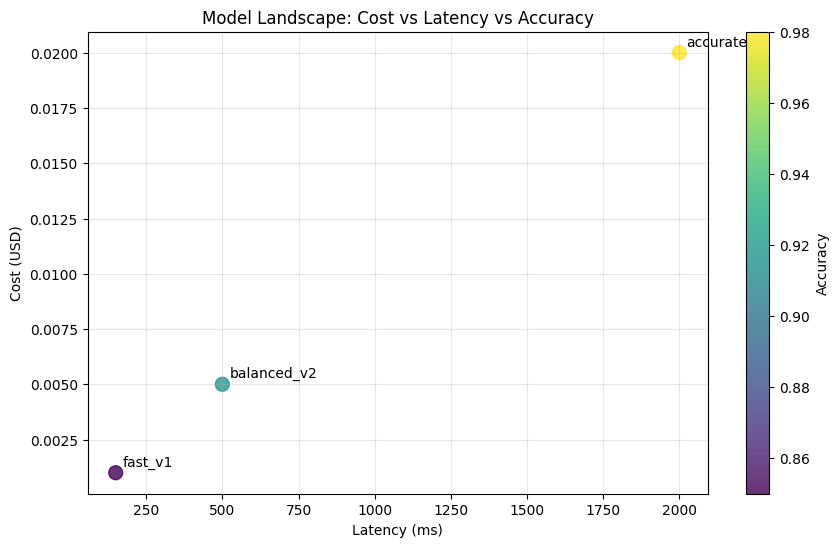

In [23]:
# 5. Visualize Trade-offs
if not profiles.empty and 'avg_latency_ms' in profiles.columns:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        profiles['avg_latency_ms'], 
        profiles['avg_cost_usd'], 
        c=profiles['avg_accuracy'], 
        cmap='viridis', 
        s=100,
        alpha=0.8
    )
    plt.colorbar(scatter, label='Accuracy')
    plt.xlabel('Latency (ms)')
    plt.ylabel('Cost (USD)')
    plt.title('Model Landscape: Cost vs Latency vs Accuracy')
    plt.grid(True, alpha=0.3)
    
    # Label points
    for i, row in profiles.iterrows():
        plt.annotate(row['model_name'], (row['avg_latency_ms'], row['avg_cost_usd']), xytext=(5, 5), textcoords='offset points')
        
    plt.show()

In [24]:
# 6. Real-time Model Health Check
import requests
from artemis_final.common.config_loader import load_global_config

def check_model_health():
    print("\nChecking Model Health...")
    try:
        config = load_global_config()
        print(f"Config Loaded: Found {len(config.models)} model instances configured.")
    except Exception as e:
        print(f"Failed to load config: {e}")
        return
    
    # Group instances by logical model name
    model_status = {}
    
    for model_cfg in config.models:
        name = model_cfg.get('name', 'unknown')
        base_url = model_cfg.get('base_url', '')
        
        if name not in model_status:
            model_status[name] = {'total': 0, 'up': 0, 'endpoints': []}
            
        model_status[name]['total'] += 1
        
        # Simple Ping 
        try:
            test_url = base_url.rstrip('/') + '/models'
            response = requests.get(test_url, timeout=2)
            
            if response.status_code == 200:
                model_status[name]['up'] += 1
                status = "UP"
            else:
                status = f"WARN ({response.status_code})"
        except Exception as e:
            status = "DOWN"
            
        model_status[name]['endpoints'].append(f"{base_url} -> {status}")
    
    # Summary
    print("\n=== Status Summary ===")
    for name, stats in model_status.items():
        up = stats['up']
        total = stats['total']
        icon = "OK" if up == total else "WARN" if up > 0 else "DOWN"
        print(f"{icon} {name}: {up}/{total} instances available")
        if up < total:
            for ep in stats['endpoints']:
                print(f"   - {ep}")

# Note: This check relies on the models serving http://host:port/v1/models.
# If your mock environment doesn't support this, you will see DOWN.
check_model_health()


Checking Model Health...
Config Loaded: Found 10 model instances configured.

=== Status Summary ===
WARN gemma_3_27b: 1/2 instances available
   - http://localhost:8800/v1 -> UP
   - http://localhost:8801/v1 -> DOWN
WARN qwen3_vl_8b_thinking: 1/2 instances available
   - http://localhost:8802/v1 -> DOWN
   - http://localhost:8803/v1 -> UP
WARN qwen2_5_vl_7b: 1/2 instances available
   - http://localhost:8804/v1 -> UP
   - http://localhost:8805/v1 -> DOWN
WARN qwen2_5_vl_3b: 1/2 instances available
   - http://localhost:8806/v1 -> DOWN
   - http://localhost:8807/v1 -> UP
WARN deepseek_ocr: 1/2 instances available
   - http://localhost:8808/v1 -> UP
   - http://localhost:8809/v1 -> DOWN
